Setup

In [38]:
%pip install -q seaborn mlflow dagshub wandb
import os, gc, json, time, math, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import preprocessing as prep
import evaluation as ev
from preprocessing import BASE_COLS, MD_COLS, WalmartFeatureBuilder, \
    feature_columns, log1p_clip, expm1_inv, calendar_frame
from evaluation import wmae

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)
os.makedirs("pictures", exist_ok=True)

CODE_PATHS = ["preprocessing.py", "evaluation.py", "models.py"]

ARCH = "NBEATS"


In [39]:
import dagshub

DAGSHUB_USER = "rkvit23"
DAGSHUB_REPO = "ML-FINAL"

dagshub.init(repo_owner=DAGSHUB_USER, repo_name=DAGSHUB_REPO, mlflow=True)
mlflow.set_tracking_uri(f"https://dagshub.com/{DAGSHUB_USER}/{DAGSHUB_REPO}.mlflow")
EXPERIMENT_NAME = f"{ARCH}_Training"
mlflow.set_experiment(EXPERIMENT_NAME)
print("MLflow experiment:", EXPERIMENT_NAME)


Initialized MLflow to track repo "rkvit23/ML-FINAL"

Repository rkvit23/ML-FINAL initialized!

MLflow experiment: NBEATS_Training


In [40]:
import wandb
WANDB_PROJECT = "walmart-final"
WANDB_ENTITY  = "rkvit23-free-university-of-tbilisi-"
wandb.login()


True

In [41]:
train_raw, test_raw, features_raw, stores_raw = prep.load_data()

TRAIN_START, TRAIN_END = train_raw.Date.min(), train_raw.Date.max()
TEST_START,  TEST_END  = test_raw.Date.min(),  test_raw.Date.max()
HORIZON = test_raw.Date.nunique()

print("train:", train_raw.shape, TRAIN_START.date(), "->", TRAIN_END.date(),
      "| weeks:", train_raw.Date.nunique())
print("test :", test_raw.shape,  TEST_START.date(),  "->", TEST_END.date(),
      "| weeks:", HORIZON)
print("series (Store, Dept) in train:", train_raw.groupby(["Store", "Dept"]).ngroups)


train: (421570, 5) 2010-02-05 -> 2012-10-26 | weeks: 143
test : (115064, 4) 2012-11-02 -> 2013-07-26 | weeks: 39
series (Store, Dept) in train: 3331


Cleaning/preprocessing

In [42]:
features_clean = prep.clean_features(features_raw)

with mlflow.start_run(run_name=f"{ARCH}_Cleaning"):
    mlflow.log_params({
        "markdown_nan": "fill 0 + MarkDown_missing flag",
        "cpi_unemployment_nan": "per-store ffill/bfill",
        "negative_sales": "kept (returns are real signal)",
        "merge": "train/test LEFT JOIN stores, features",
    })
    mlflow.log_metrics({
        "n_rows_train": len(train_raw),
        "n_rows_test": len(test_raw),
        "n_series": train_raw.groupby(["Store", "Dept"]).ngroups,
        "n_negative_sales": int((train_raw.Weekly_Sales < 0).sum()),
        "pct_markdown_missing": float(features_raw[MD_COLS].isna().all(axis=1).mean()),
    })
print("cleaning done")


🏃 View run NBEATS_Cleaning at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/2abf28f17d934648a42329ed1802166a
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4
cleaning done


Data preparation for a global model

In [43]:
dm = prep.build_series_matrix(train_raw, HORIZON)
Y, Ys, scale = dm.Y, dm.Ys, dm.scale
series_idx, all_dates, T = dm.series_idx, dm.all_dates, dm.T
w_week, S = dm.w_week, dm.n_series
VAL_CUT, val_dates = dm.val_cut, dm.val_dates
val_actual = train_raw[train_raw.Date >= val_dates[0]][
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()

with mlflow.start_run(run_name=f"{ARCH}_Windowing"):
    mlflow.log_params({
        "fill_missing_weeks": "0 (dept not trading)",
        "negatives": "clipped to 0",
        "scaling": "per-series mean, floor=1.0",
        "strategy": "global model, direct multi-horizon H=39",
        "val": "last 39 weeks of train",
    })
    mlflow.log_metrics({"n_series": S, "n_weeks": T, "obs_fraction": dm.obs_frac})
print(f"matrix {Y.shape} | observed fraction {dm.obs_frac:.3f} | VAL_CUT={VAL_CUT}")


🏃 View run NBEATS_Windowing at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/e8cd7be0529d4b5a8983af82b74399c0
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4
matrix (3331, 143) | observed fraction 0.885 | VAL_CUT=104


In [44]:
val_start_target = np.datetime64(TEST_START - pd.DateOffset(years=1))
VAL_CUT = int(np.argmin(np.abs(all_dates.values - val_start_target)))
val_dates = all_dates[VAL_CUT:VAL_CUT + HORIZON]
val_actual = train_raw[train_raw.Date.isin(val_dates)][
    ["Store", "Dept", "Date", "Weekly_Sales", "IsHoliday"]].copy()

print("VAL_CUT:", VAL_CUT, "| val:", pd.Timestamp(val_dates[0]).date(),
      "->", pd.Timestamp(val_dates[-1]).date(),
      "| weeks:", len(val_dates),
      "| holiday weeks:", val_actual.groupby("Date").IsHoliday.first().sum())

VAL_CUT: 91 | val: 2011-11-04 -> 2012-07-27 | weeks: 39 | holiday weeks: 3


In [45]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

def make_windows(L, H, t_max):
    """Sliding windows over all series: input [t-L, t) -> target [t, t+H), t <= t_max-H."""
    xs, ys, ws = [], [], []
    for t in range(L, t_max - H + 1):
        xs.append(Ys[:, t - L:t])
        ys.append(Ys[:, t:t + H])
        ws.append(np.tile(w_week[t:t + H], (S, 1)))
    X = np.concatenate(xs); Yt = np.concatenate(ys); W = np.concatenate(ws)
    SC = np.tile(scale[:, 0], t_max - H + 1 - L)
    keep = X.sum(axis=1) > 0
    return (torch.tensor(X[keep]), torch.tensor(Yt[keep]),
            torch.tensor(W[keep]), torch.tensor(SC[keep]))

def forecast_matrix(model, L, t_end):
    """Forecast all series (S, H) in dollars, input = last L weeks before t_end."""
    model.eval()
    with torch.no_grad():
        x = torch.tensor(Ys[:, t_end - L:t_end]).to(DEVICE)
        return model(x).cpu().numpy() * scale

def val_wmae_of(model, L):
    pred = forecast_matrix(model, L, VAL_CUT)
    dfp = pd.DataFrame(pred, index=series_idx, columns=val_dates)
    dfp.columns.name = "Date"
    long = dfp.stack().rename("pred").reset_index()
    m = val_actual.merge(long, on=["Store", "Dept", "Date"], how="left")
    m["pred"] = m["pred"].fillna(0).clip(lower=0)
    return wmae(m.Weekly_Sales, m.pred, m.IsHoliday), m

def train_model(model, cfg, run_name, log_wandb=True, init_wandb=True,
                t_max=None, epochs=None, eval_val=True):
    """Train one config: weighted-L1 loss, early stopping on val WMAE,
    logging to BOTH MLflow and W&B."""
    t_max = t_max or VAL_CUT
    X, Yt, W, SC = make_windows(cfg["L"], HORIZON, t_max)
    dl_ = DataLoader(TensorDataset(X, Yt, W, SC),
                     batch_size=cfg.get("batch", 1024), shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=cfg.get("lr", 1e-3),
                           weight_decay=cfg.get("weight_decay", 0.0))
    n_epochs = epochs or cfg.get("epochs", 40)
    patience = cfg.get("patience", 6)
    best_v, best_ep, best_state, bad = float("inf"), 0, None, 0
    hist = []
    if log_wandb and init_wandb:
        wandb.init(project=WANDB_PROJECT, entity=WANDB_ENTITY, name=run_name,
                   group=f"{ARCH}_Training", config=cfg, finish_previous=True)
    with mlflow.start_run(run_name=run_name):
        mlflow.log_params({k: str(v) for k, v in cfg.items()})
        n_par = sum(p.numel() for p in model.parameters())
        mlflow.log_param("n_parameters", n_par)
        for ep in range(1, n_epochs + 1):
            model.train(); tot, nb = 0.0, 0
            for xb, yb, wb, scb in dl_:
                xb, yb, wb, scb = [a.to(DEVICE) for a in (xb, yb, wb, scb)]
                pred = model(xb)
                if cfg.get("scale_weighted_loss"):
                    w_eff = wb * (scb / scb.mean()).unsqueeze(1)
                else:
                    w_eff = wb
                loss = (w_eff * (pred - yb).abs()).mean()
                opt.zero_grad(); loss.backward(); opt.step()
                tot += loss.item(); nb += 1
            row = {"epoch": ep, "train_loss": tot / nb}
            if eval_val:
                vw, _ = val_wmae_of(model, cfg["L"])
                row["val_wmae"] = vw
                if vw < best_v - 1e-6:
                    best_v, best_ep, bad = vw, ep, 0
                    best_state = {k: v.detach().cpu().clone()
                                  for k, v in model.state_dict().items()}
                else:
                    bad += 1
            mlflow.log_metrics({k: v for k, v in row.items() if k != "epoch"}, step=ep)
            if log_wandb:
                wandb.log(row)
            hist.append(row)
            if eval_val and bad >= patience:
                print(f"  early stop @ epoch {ep} (best {best_v:,.1f} @ {best_ep})")
                break
        if eval_val and best_state is not None:
            model.load_state_dict(best_state)
            mlflow.log_metric("best_val_wmae", best_v)
            mlflow.log_metric("best_epoch", best_ep)
        if log_wandb:
            if eval_val:
                wandb.summary["best_val_wmae"] = best_v
                wandb.summary["best_epoch"] = best_ep
                wandb.summary["n_parameters"] = n_par
            if init_wandb:
                wandb.finish()
    return best_v, best_ep, hist

device: cuda


## Model implementation and configurations

In [46]:
from models import NBeatsBlock, NBeats, build_model

CONFIGS = [
    dict(name="generic_w256",   L=52, stacks=[("generic", 3, 256, 4)], lr=1e-3),
    dict(name="generic_w512",   L=52, stacks=[("generic", 4, 512, 4)], lr=5e-4),
    dict(name="interpretable",  L=52, stacks=[("trend", 3, 256, 4),
                                              ("seasonality", 3, 256, 4)], lr=1e-3),
    dict(name="interp_generic", L=52, stacks=[("trend", 2, 256, 4),
                                              ("seasonality", 2, 256, 4),
                                              ("generic", 2, 256, 4)], lr=1e-3),
    dict(name="generic_scaleW", L=52, stacks=[("generic", 3, 256, 4)], lr=1e-3,
         scale_weighted_loss=True),
]

SWEEP_SPACE = {
    "width": {"values": [128, 256, 512]},
    "n_blocks": {"values": [2, 3, 4]},
    "depth": {"values": [2, 4]},
    "lr": {"distribution": "log_uniform_values", "min": 1e-4, "max": 3e-3},
}

def cfg_from_sweep(wc):
    return dict(L=52, stacks=[("generic", wc["n_blocks"], wc["width"], wc["depth"])],
                lr=wc["lr"])

In [47]:
_m = build_model(CONFIGS[0], HORIZON).to(DEVICE)
_x = torch.rand(8, CONFIGS[0]["L"], device=DEVICE)
_out = _m(_x)
assert _out.shape == (8, HORIZON), _out.shape
_out.abs().mean().backward()
_ok = sum(int(p.grad is not None and torch.isfinite(p.grad).all())
          for p in _m.parameters() if p.requires_grad)
print(f"forward OK {tuple(_out.shape)} | tensors with finite grads: {_ok}")
del _m, _x, _out


forward OK (8, 39) | tensors with finite grads: 34


Comparing configurations


In [48]:
RESULTS, HISTORIES = {}, {}
best_overall = {"wmae": float("inf"), "cfg": None, "epochs": None}
BEST_MODEL = None

for cfg in CONFIGS:
    torch.manual_seed(SEED); np.random.seed(SEED)
    model = build_model(cfg, HORIZON).to(DEVICE)
    n_par = sum(p.numel() for p in model.parameters())
    print(f"\n=== {cfg['name']}  ({n_par:,} params) ===")
    v, ep, hist = train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}", log_wandb=False, init_wandb=False)
    RESULTS[cfg["name"]] = {"val_wmae": round(v, 1), "best_epoch": ep, "params": n_par}
    HISTORIES[cfg["name"]] = hist
    if v < best_overall["wmae"]:
        best_overall = {"wmae": v, "cfg": cfg, "epochs": ep}
        BEST_MODEL = model

res_df = pd.DataFrame(RESULTS).T.sort_values("val_wmae")
print("\n", res_df)
BEST_CFG, BEST_EPOCHS = best_overall["cfg"], max(best_overall["epochs"], 1)
print("\nbest config:", BEST_CFG["name"], "| val WMAE:", round(best_overall["wmae"], 1))



=== generic_w256  (702,993 params) ===
  early stop @ epoch 39 (best 3,229.8 @ 33)
🏃 View run NBEATS_generic_w256 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/fff863ab477443d391366ea3f928143d
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4

=== generic_w512  (3,447,148 params) ===
  early stop @ epoch 11 (best 3,686.1 @ 5)
🏃 View run NBEATS_generic_w512 at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/d7533cf220aa43049b915a002ca7bafe
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4

=== interpretable  (1,277,952 params) ===
  early stop @ epoch 36 (best 3,033.1 @ 30)
🏃 View run NBEATS_interpretable at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/2aa37eaf5de24322a32d9187e9748ee5
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4

=== interp_generic  (1,320,630 params) ===
  early stop @ epoch 27 (best 3,069.5 @ 21)
🏃 View run

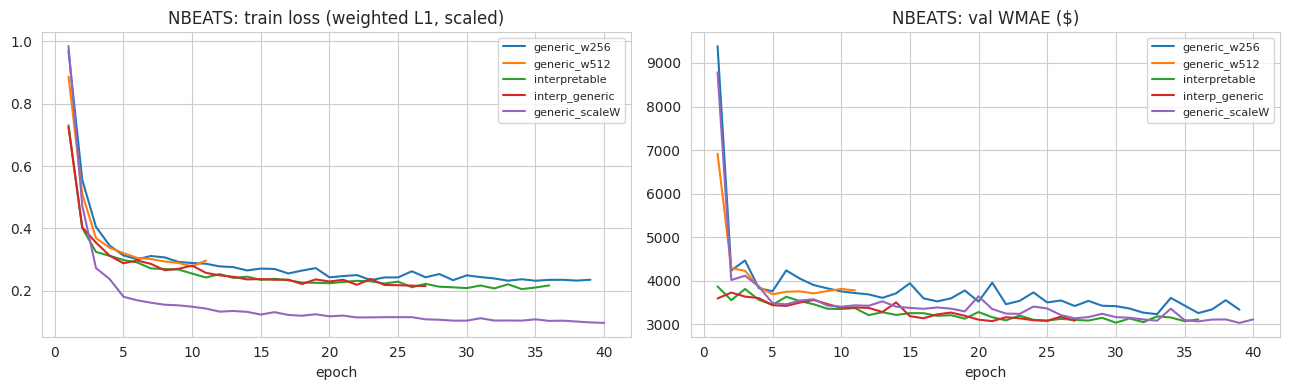

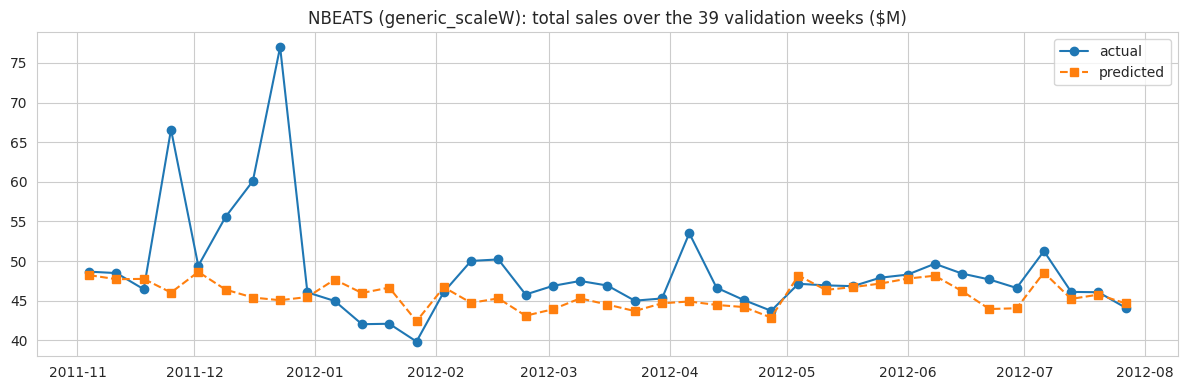

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for name, hist in HISTORIES.items():
    h = pd.DataFrame(hist)
    axes[0].plot(h.epoch, h.train_loss, label=name)
    if "val_wmae" in h:
        axes[1].plot(h.epoch, h.val_wmae, label=name)
axes[0].set_title(f"{ARCH}: train loss (weighted L1, scaled)")
axes[1].set_title(f"{ARCH}: val WMAE ($)")
for ax in axes:
    ax.set_xlabel("epoch"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_curves.png", dpi=120); plt.show()

_, mval = val_wmae_of(BEST_MODEL, BEST_CFG["L"])
fig, ax = plt.subplots(figsize=(12, 4))
a = mval.groupby("Date").Weekly_Sales.sum() / 1e6
p = mval.groupby("Date").pred.sum() / 1e6
ax.plot(a.index, a.values, "o-", label="actual")
ax.plot(p.index, p.values, "s--", label="predicted")
ax.set_title(f"{ARCH} ({BEST_CFG['name']}): total sales over the 39 validation weeks ($M)")
ax.legend()
plt.tight_layout(); plt.savefig(f"pictures/{ARCH.lower()}_val_total.png", dpi=120); plt.show()


Wandb sweep

In [50]:
RUN_SWEEP = False
SWEEP_COUNT = 8

if RUN_SWEEP:
    sweep_id = wandb.sweep(
        {"method": "bayes",
         "metric": {"name": "best_val_wmae", "goal": "minimize"},
         "parameters": SWEEP_SPACE},
        project=WANDB_PROJECT, entity=WANDB_ENTITY)

    def _sweep_train():
        run = wandb.init(group=f"{ARCH}_Sweep")
        cfg = cfg_from_sweep(dict(wandb.config))
        cfg["name"] = f"sweep_{run.id}"
        torch.manual_seed(SEED)
        model = build_model(cfg, HORIZON).to(DEVICE)
        train_model(model, cfg, run_name=f"{ARCH}_{cfg['name']}",
                    log_wandb=True, init_wandb=False)

    wandb.agent(sweep_id, function=_sweep_train, count=SWEEP_COUNT)


Final model + pipeline + submission


In [51]:
REGISTER_AS_BEST = False

torch.manual_seed(SEED)
final_model = build_model(BEST_CFG, HORIZON).to(DEVICE)
_ = train_model(final_model, BEST_CFG, run_name=f"{ARCH}_Final_Refit",
                log_wandb=False, t_max=T, epochs=BEST_EPOCHS, eval_val=False)

fb_table, GLOBAL_MEAN = prep.make_fallback_table(train_raw)


class TorchForecastPipeline(mlflow.pyfunc.PythonModel):

    def __init__(self, build_fn, cfg, state_dict, hist_tail, scale_vec,
                 series_index, train_end, horizon, fallback, global_mean):
        self.build_fn = build_fn
        self.cfg = {k: v for k, v in cfg.items()}
        self.state_dict = state_dict
        self.hist_tail = hist_tail
        self.scale_vec = scale_vec
        self.pos = {sd: i for i, sd in enumerate(series_index)}
        self.train_end = train_end
        self.horizon = horizon
        self.fallback = fallback
        self.global_mean = global_mean
        self._fc = None

    def _forecast(self):
        if self._fc is None:
            import torch as _t
            model = self.build_fn(self.cfg, self.horizon)
            model.load_state_dict(self.state_dict)
            model.eval()
            with _t.no_grad():
                self._fc = (model(_t.tensor(self.hist_tail, dtype=_t.float32)).numpy()
            * self.scale_vec).clip(min=0)
        return self._fc

    def predict(self, context, model_input):
        df = model_input.copy()
        df["Date"] = pd.to_datetime(df["Date"])
        fc = self._forecast()
        k = (((df.Date - self.train_end).dt.days // 7) - 1).clip(0, self.horizon - 1)
        k = k.astype(int).values
        idx = np.array([self.pos.get((s, d), -1)
                        for s, d in zip(df.Store, df.Dept)])
        woy = df.Date.dt.isocalendar().week.astype(int)
        fb = (pd.DataFrame({"Dept": df.Dept.values, "WeekOfYear": woy.values})
              .merge(self.fallback, on=["Dept", "WeekOfYear"], how="left")
              ["Dept_WOY_Med"].fillna(self.global_mean).values)
        return np.where(idx >= 0, fc[idx.clip(min=0), k], fb)


wrapper = TorchForecastPipeline(
    build_fn=build_model, cfg=BEST_CFG,
    state_dict={k: v.cpu() for k, v in final_model.state_dict().items()},
    hist_tail=Ys[:, T - BEST_CFG["L"]:T], scale_vec=scale,
    series_index=list(series_idx), train_end=TRAIN_END, horizon=HORIZON,
    fallback=fb_table, global_mean=GLOBAL_MEAN)

test_pred = wrapper.predict(None, test_raw[["Store", "Dept", "Date"]])
assert len(test_pred) == len(test_raw) and np.isfinite(test_pred).all()

with mlflow.start_run(run_name=f"{ARCH}_Final_Pipeline"):
    mlflow.log_params({f"best_{k}": str(v) for k, v in BEST_CFG.items()})
    mlflow.log_metric("val_wmae", best_overall["wmae"])
    mlflow.log_metric("final_epochs", BEST_EPOCHS)
    for _p in [f"pictures/{ARCH.lower()}_curves.png",
               f"pictures/{ARCH.lower()}_val_total.png"]:
        if os.path.exists(_p):
            mlflow.log_artifact(_p)
    mlflow.pyfunc.log_model(
        "model", python_model=wrapper, code_paths=CODE_PATHS,
        registered_model_name="WalmartBestModel" if REGISTER_AS_BEST else None)
    run_id = mlflow.active_run().info.run_id
print("pipeline logged, run_id =", run_id)

sub = ev.make_submission(test_raw, test_pred, f"submission_{ARCH}.csv")
print("saved:", f"submission_{ARCH}.csv")


🏃 View run NBEATS_Final_Refit at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/2df65231f93a4c4a96292b1ec364f717
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4


/usr/local/lib/python3.12/dist-packages/mlflow/pyfunc/utils/data_validation.py:187: UserWarning: Add type hints to the `predict` method to enable data validation and automatic signature inference during model logging. Check https://mlflow.org/docs/latest/model/python_model.html#type-hint-usage-in-pythonmodel for more details.
  color_warning(
2026/07/11 00:40:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/11 00:40:36 WARNING mlflow.pyfunc: Passing a Python object as `python_model` causes it to be serialized using CloudPickle, it requires exercising caution as Python object serialization mechanisms may execute arbitrary code during deserialization.Consider using a file path (str or Path) instead. See https://mlflow.org/docs/latest/ml/model/models-from-code/ for details.
2026/07/11 00:40:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement 

🏃 View run NBEATS_Final_Pipeline at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4/runs/5e06b6435a9e4e069461f12b407b6904
🧪 View experiment at: https://dagshub.com/rkvit23/ML-FINAL.mlflow/#/experiments/4
pipeline logged, run_id = 5e06b6435a9e4e069461f12b407b6904
saved: submission_NBEATS.csv
